# Projet Api Immo Lille 

In [1]:
#import utile pour le projet machine learning 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
#création dataframe pandas 
df = pd.read_csv("../data/lille_2022.csv")

In [3]:
#Apreçu jeu de donné 
print(df.shape)
df.head()

(11354, 44)


,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain,prix_m2
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,0,1.0,Maison,NaN,82.0,5.0,S,NaN,70.0,2681.707317
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,2,2.0,Appartement,NaN,63.0,3.0,NaN,NaN,NaN,2936.507937
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,2,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN,inf
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN,inf
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2022,Vente,...,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN,inf


 3️⃣ Premier Filtrage :
 - logements à 4 pièces
 - colonnes utiles
 - me prix au m2 est déja integres 

In [9]:
df = df[df["Nombre pieces principales"] == 4 ]

colonnes_utiles = [
    "Surface reelle bati",
    "Nombre pieces principales",
    "Type local",
    "Surface terrain",
    "Nombre de lots",
    "prix_m2"
]
df = df[colonnes_utiles]
df.head()

,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,prix_m2
18,165.0,4.0,Maison,121.0,0,1848.484848
23,92.0,4.0,Appartement,NaN,1,3989.130435
26,70.0,4.0,Appartement,NaN,2,2428.571429
58,105.0,4.0,Appartement,NaN,2,3383.809524
62,120.0,4.0,Appartement,NaN,1,3937.500000


In [24]:
# Séparer maisons / appartements
df_maisons = df[df['Type local'].str.lower().str.contains('maison')]
df_apparts = df[df['Type local'].str.lower().str.contains('appartement')]

# Nettoyage des NA sur les colonnes utilisées
cols = ['Surface reelle bati', 'Nombre pieces principales', 'Surface terrain', 'Nombre de lots', 'prix_m2']
df_maisons = df_maisons[cols].dropna()
df_apparts = df_apparts[cols].dropna()

In [25]:
df_apparts.info()
df_apparts
#print(df_apparts.isnull())

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 394 to 10447
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Surface reelle bati        49 non-null     float64
 1   Nombre pieces principales  49 non-null     float64
 2   Surface terrain            49 non-null     float64
 3   Nombre de lots             49 non-null     int64  
 4   prix_m2                    49 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 2.3 KB


,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,prix_m2
394,116.0,4.0,155.0,0,1465.517241
575,170.0,4.0,221.0,0,3058.823529
940,53.0,4.0,105.0,0,27735.849057
1249,65.0,4.0,176.0,0,9230.769231
1251,65.0,4.0,176.0,0,9230.769231
1252,65.0,4.0,176.0,0,9230.769231
1253,65.0,4.0,176.0,0,9230.769231
1525,72.0,4.0,59.0,0,416.666667
1529,72.0,4.0,59.0,0,416.666667
1624,130.0,4.0,1207.0,0,9230.769231


In [ ]:
#pd.set_option('display.max_rows', None)  # Affiche toutes les lignes
df_maisons.info()
df_maisons

#print(df_maisons.isnull())

<class 'pandas.core.frame.DataFrame'>
Index: 340 entries, 18 to 11353
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Surface reelle bati        340 non-null    float64
 1   Nombre pieces principales  340 non-null    float64
 2   Surface terrain            340 non-null    float64
 3   Nombre de lots             340 non-null    int64  
 4   prix_m2                    340 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 15.9 KB


,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,prix_m2
18,165.0,4.0,121.0,0,1848.484848
65,64.0,4.0,127.0,0,3545.312500
161,70.0,4.0,192.0,0,2941.285714
168,62.0,4.0,96.0,0,2572.580645
176,72.0,4.0,135.0,0,3609.722222
231,80.0,4.0,182.0,0,2750.000000
312,65.0,4.0,47.0,0,3129.230769
365,88.0,4.0,117.0,0,3244.318182
379,93.0,4.0,131.0,0,3062.365591
380,123.0,4.0,153.0,0,2032.520325


In [11]:
df_apparts

,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,prix_m2
394,116.0,4.0,155.0,0,1465.517241
575,170.0,4.0,221.0,0,3058.823529
940,53.0,4.0,105.0,0,27735.849057
1249,65.0,4.0,176.0,0,9230.769231
1251,65.0,4.0,176.0,0,9230.769231
1252,65.0,4.0,176.0,0,9230.769231
1253,65.0,4.0,176.0,0,9230.769231
1525,72.0,4.0,59.0,0,416.666667
1529,72.0,4.0,59.0,0,416.666667
1624,130.0,4.0,1207.0,0,9230.769231


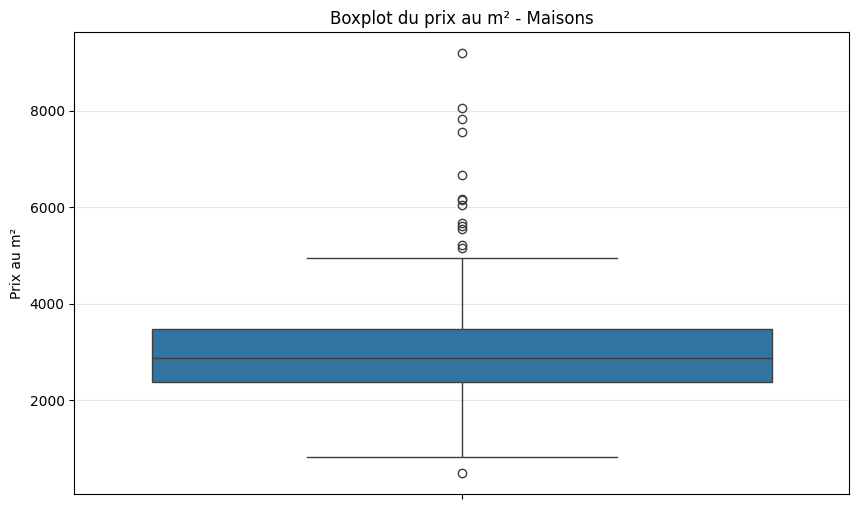

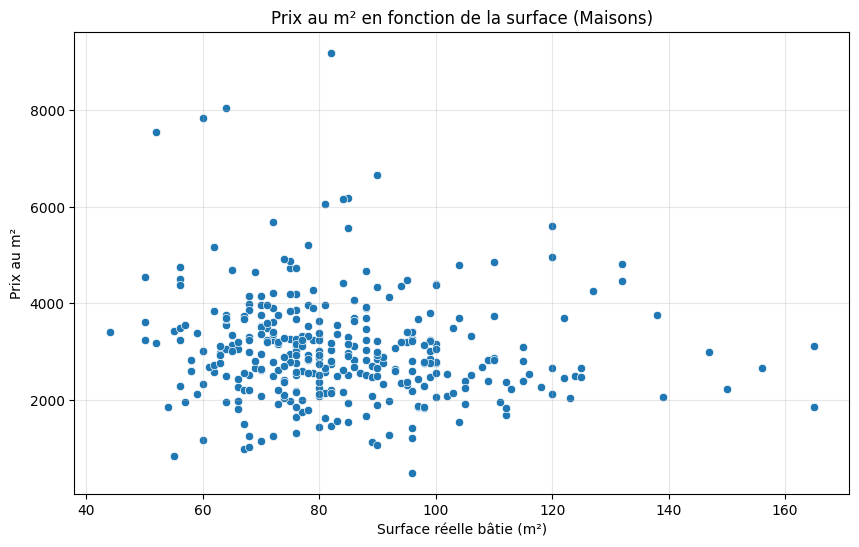

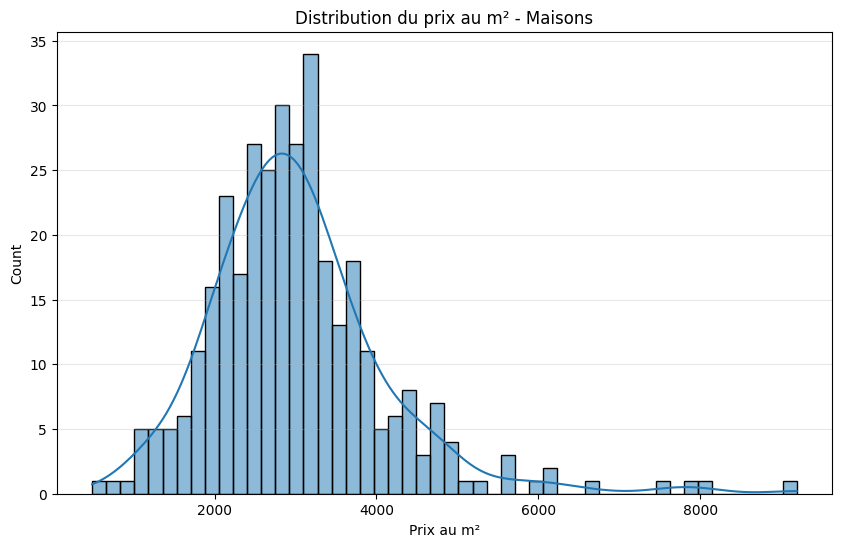

In [30]:
# On suppose que ton DataFrame filtré pour les maisons est dans `df_maisons`
# Et que la variable cible est `prix_m2`

plt.figure(figsize=(10, 6))

# 1) Boxplot pour visualiser les valeurs extrêmes
sns.boxplot(data=df_maisons, y='prix_m2')
plt.title('Boxplot du prix au m² - Maisons')
plt.ylabel('Prix au m²')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2) Nuage de points entre surface et prix_m2 pour voir la tendance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_maisons, x='Surface reelle bati', y='prix_m2')
plt.title('Prix au m² en fonction de la surface (Maisons)')
plt.xlabel('Surface réelle bâtie (m²)')
plt.ylabel('Prix au m²')
plt.grid(alpha=0.3)
plt.show()

# 3) Distribution des prix au m²
plt.figure(figsize=(10, 6))
sns.histplot(df_maisons['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² - Maisons')
plt.xlabel('Prix au m²')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

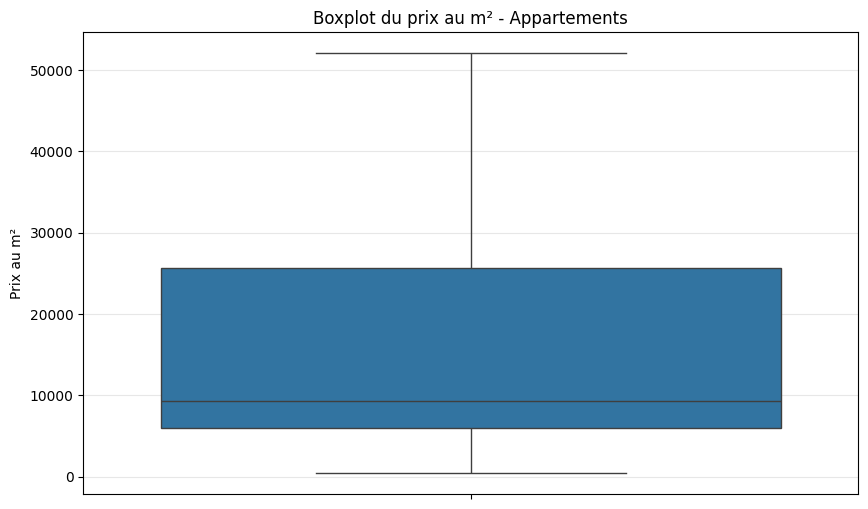

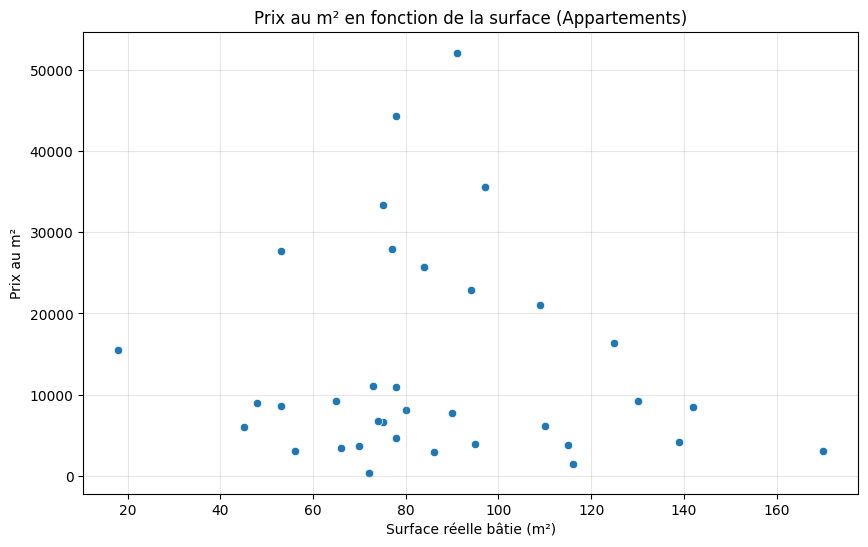

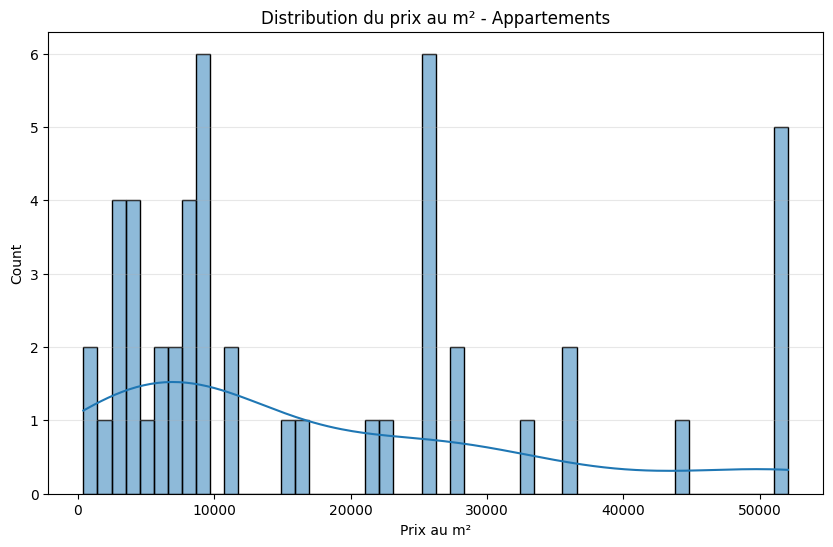

In [31]:
# On suppose que ton DataFrame filtré pour les appartements est dans `df_appartements`

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_apparts, y='prix_m2')
plt.title('Boxplot du prix au m² - Appartements')
plt.ylabel('Prix au m²')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_apparts, x='Surface reelle bati', y='prix_m2')
plt.title('Prix au m² en fonction de la surface (Appartements)')
plt.xlabel('Surface réelle bâtie (m²)')
plt.ylabel('Prix au m²')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df_apparts['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² - Appartements')
plt.xlabel('Prix au m²')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
#detect nan et zero et les renvoie dans un dataframe
def detect_nan_and_zeros(df: pd.DataFrame) -> pd.DataFrame:
    # On ne garde que les colonnes numériques
    num_cols = df.select_dtypes(include='number').columns
    results = []
    for col in num_cols:
        n_nan = df[col].isna().sum()
        n_zero = (df[col] == 0).sum()
        results.append({
            'column': col,
            'n_nan': n_nan,
            'n_zero': n_zero
        })
    return pd.DataFrame(results)

df_test_maisons=detect_nan_and_zeros(df_maisons)
df_test_apparts=detect_nan_and_zeros(df_apparts)


In [ ]:

df_test_apparts

,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,0
3,Nombre de lots,0,49
4,prix_m2,0,0


In [28]:
df_test_maisons

,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,0
3,Nombre de lots,0,340
4,prix_m2,0,0


In [32]:
df_maisons.corr()

,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,prix_m2
Surface reelle bati,1.000000,NaN,0.240720,NaN,-0.105272
Nombre pieces principales,NaN,NaN,NaN,NaN,NaN
Surface terrain,0.240720,NaN,1.000000,NaN,0.033024
Nombre de lots,NaN,NaN,NaN,NaN,NaN
prix_m2,-0.105272,NaN,0.033024,NaN,1.000000


In [18]:
df_apparts.corr()

,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,prix_m2
Surface reelle bati,1.000000,NaN,0.418607,NaN,0.010009
Nombre pieces principales,NaN,NaN,NaN,NaN,NaN
Surface terrain,0.418607,NaN,1.000000,NaN,0.079202
Nombre de lots,NaN,NaN,NaN,NaN,NaN
prix_m2,0.010009,NaN,0.079202,NaN,1.000000


In [ ]:
# changement df_maisons et df_apparts pour supprimer nombres pieces principales et nombre de lots 

colonnes_utiles = [
    "Surface reelle bati",
    "Surface terrain",
    "prix_m2"
]
df_maisons = df_maisons[colonnes_utiles]
df_apparts = df_apparts[colonnes_utiles]
df_maisons.corr()

,Surface reelle bati,Surface terrain,prix_m2
18,165.0,121.0,1848.484848
65,64.0,127.0,3545.312500
161,70.0,192.0,2941.285714
168,62.0,96.0,2572.580645
176,72.0,135.0,3609.722222


In [ ]:
df_apparts.corr()

In [ ]:
# Detection outliers

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return lower_bound, upper_bound, outliers

lb, ub, outliers_app = detect_outliers_iqr(df_apparts, "prix_m2")
print(f"{len(outliers_app)} valeurs aberrantes détectées sur prix_m2")